In [3]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import os

In [4]:
os.chdir(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos')

In [ ]:
'''import os
# Lista de novas espécies
nomes = [
  "Camarao_art", "Camarao_ind", "Camarao_art_ind", "Cam_sete_barbas_art", "Cam_sete_barbas_ind", "Cam_branco_art", "Cam_branco_ind", "Cam_rosa_art", "Cam_rosa_ind", "Cam_barba_ruca_art", "Cam_barba_ruca_ind", "Cam_santana_art", "Cam_santana_ind", "Cam_crista_art", "Cam_crista_ind", "Caranguejo_ind", "Caran_uca_art", "Guaiamum_art", "Caran_santola_art", "Caran_real_ind", "Caran_ermitao_art", "Caran_goia_art", "Caran_goia_ind", "Lagosta_art", "Lagosta_ind", "Lagosta_art_ind", "Lago_sapateira_art", "Lago_sapateira_ind", "Lagostim_art", "Lagostim_ind", "Siri_portunidae_art", "Siri_portunidae_ind", "Siri_azul_art", "Siri_azul_ind", "Siri_azul_art_ind", "Siri_candeia_art", "Siri_candeia_ind", "Siri_chita_art", "Siri_chita_ind", "Tamburutaca_art", "Tamburutaca_ind", "Outros_crust_art", "Outros_crust_ind",



]

# Definir o caminho base
caminho_base = os.getcwd()

# Criar as pastas para cada espécie
for nome in nomes:
    pasta = os.path.join(caminho_base, f"pesos prop {nome}")
    os.makedirs(pasta, exist_ok=True)
    print(f"Criada a pasta: {pasta}")'''

Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Camarao_art
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Camarao_ind
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Camarao_art_ind
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_sete_barbas_art
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_sete_barbas_ind
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_branco_art
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_branco_ind
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_rosa_art
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_rosa_ind
Criada a pasta: C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop Cam_barba_ruca_art
Criad

In [128]:
#Coletando dados

df = pd.read_excel('R.xlsx')

#Dados iniciais
df_especies = df[['Ano','Cam_branco_art', 'Cam_rosa_art', 'Cam_sete_barbas_art']]
anos_para_prever = np.array([*range(1950,1990),*range(1995,1996)])
df_especies = df_especies[['Ano','Cam_branco_art', 'Cam_rosa_art', 'Cam_sete_barbas_art']].dropna().reset_index(drop=True)

lista_de_prop=[] #lista onde ficam os arrays com as proporções para cada especie
especies = df_especies.drop('Ano',axis=1).columns.to_numpy() #lista das especies

#Coluna da soma
for i in range(len(df_especies['Ano'])):
  df_especies.loc[i,'Soma'] = df_especies.iloc[i,1:].sum() 


for k in range(len(especies)):

     dados = df_especies[['Ano',especies[k],'Soma']]
     
     #Fazendo as proporções de cada especie em relação à soma
     for i in range(len(dados['Ano'])):
       dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
     
     
     anos_com_dados = dados["Ano"].values
     todos_anos = np.concatenate((anos_para_prever, anos_com_dados))
     todos_anos.sort()
     
     prop= dados['Prop_'+especies[k]].values
     lista_de_prop.append(prop)
     print(dados.head())

     

    Ano  Cam_branco_art    Soma  Prop_Cam_branco_art
0  1996          2755.5  5573.0             0.494437
1  1997          2826.0  5811.5             0.486277
2  1998          2812.5  5713.5             0.492255
3  1999          2851.0  6510.0             0.437942
4  2000          2822.0  5913.0             0.477254
    Ano  Cam_rosa_art    Soma  Prop_Cam_rosa_art
0  1996         650.0  5573.0           0.116634
1  1997         684.0  5811.5           0.117698
2  1998         667.0  5713.5           0.116741
3  1999        1242.0  6510.0           0.190783
4  2000         811.0  5913.0           0.137155
    Ano  Cam_sete_barbas_art    Soma  Prop_Cam_sete_barbas_art
0  1996               2167.5  5573.0                  0.388929
1  1997               2301.5  5811.5                  0.396025
2  1998               2234.0  5713.5                  0.391004
3  1999               2417.0  6510.0                  0.371275
4  2000               2280.0  5913.0                  0.385591


C:\Users\PC\AppData\Local\Temp\ipykernel_20124\535027117.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_20124\535027117.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_20124\535027117.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [129]:
#Normalização dos dados
ano_mean = np.mean(anos_com_dados)
ano_std = np.std(anos_com_dados)
anos_para_prever_norm = (anos_para_prever - ano_mean)/ano_std
anos_com_dados_norm = (anos_com_dados - ano_mean)/ano_std

lista_prop_norm=[]  #lista com as proporçãoes normalizads para cada especie

lista_prop_mean=[]  #listas para aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([-0.61094537, -0.77911361, -0.65591827, -1.77522304, -0.96507584,
        1.17761829,  1.12363971,  1.33808338,  1.34282486,  0.34370241,
       -0.27093405, -0.26865847]), array([ 0.46867664,  0.49404922,  0.47123518,  2.23704774,  0.95809093,
       -0.90940979, -0.91826619, -1.32376911, -1.33014098, -0.40761839,
        0.13284032,  0.12726443]), array([ 0.8786526 ,  1.50257291,  1.06108901, -0.67349067,  0.58519865,
       -1.67144197, -1.40850184, -0.82844919, -0.82518715,  0.03639243,
        0.66615869,  0.67700653])]


In [130]:
#Função para fazer o Fit do modelo e salvar seus pesos para cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [131]:
#Fit do modelo
Adam= keras.optimizers.Nadam(learning_rate=0.001)
Nadam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[45,45,45,45,45,45,45,45,45,45,45,45,45,45,45]
lista_de_otimizadores=[Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam,Nadam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [132]:
#Previsões para cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_para_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos para 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


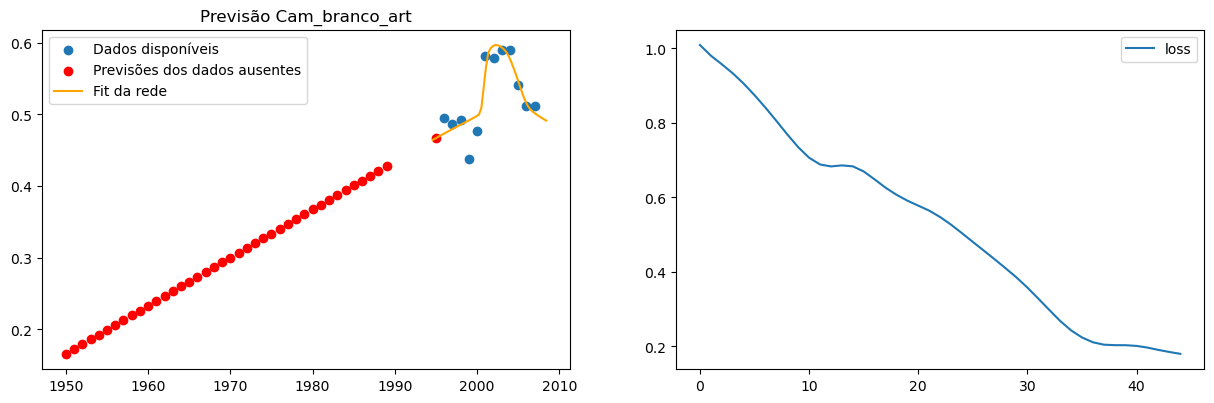

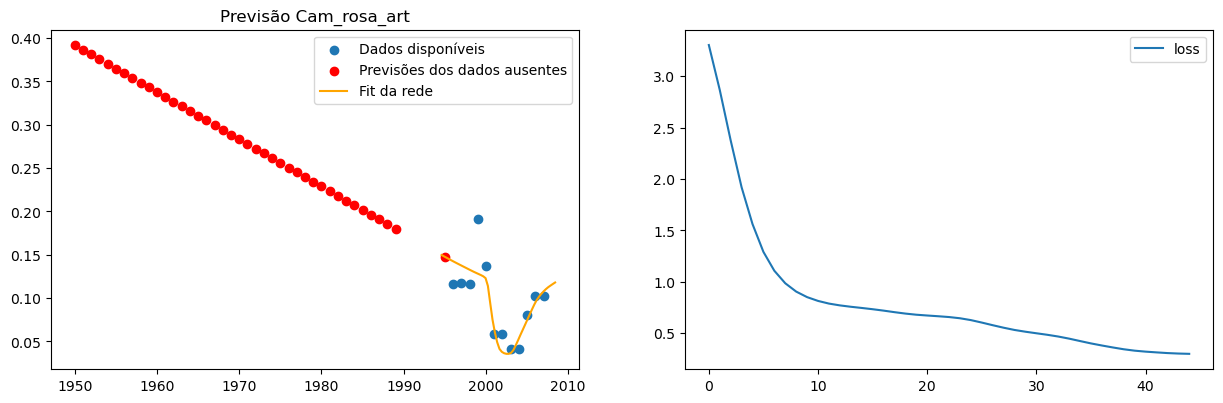

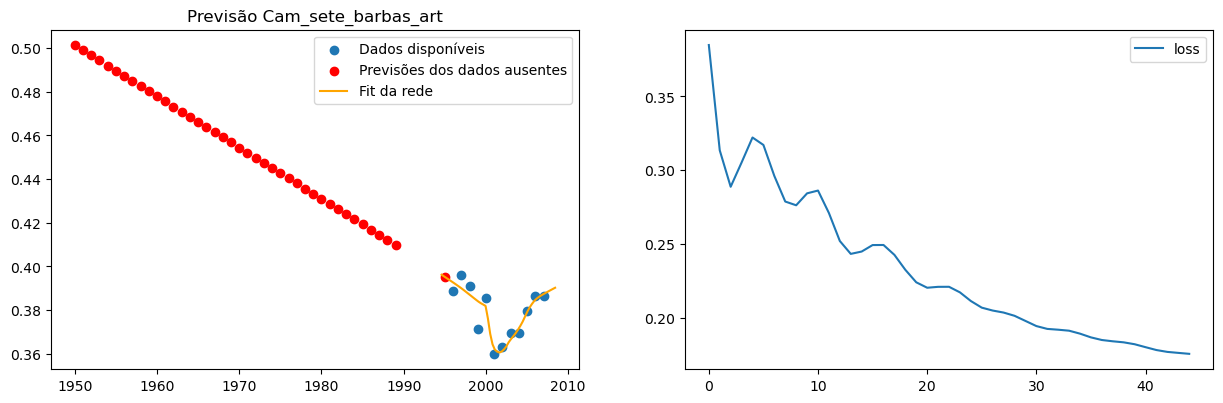

In [133]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,15))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_para_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [134]:
#Lista de anos sem buracos normalizada e sua predição      (para poder me referir por indices)
anos = np.arange(1950,np.max(anos_para_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos para cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [135]:
#Soma das proporções
prop_soma = np.zeros(len(anos))
for k in range(len(especies)):
    prop_soma+=lista_prev_continua[k]

#Dividindo proporções pela soma para que de sempre 1
for k in range(len(especies)):
  lista_prev_continua[k] /= prop_soma 
print(lista_prev_continua[1])

[0.3700529  0.36528838 0.3605142  0.3557303  0.35093665 0.3461333
 0.3413201  0.33649713 0.33166423 0.3268215  0.32196888 0.31710616
 0.31223345 0.30735078 0.30245808 0.29755536 0.29264256 0.2877204
 0.28278813 0.2778455  0.2728927  0.2679296  0.26295623 0.25797248
 0.25297764 0.24797305 0.24295847 0.23793316 0.23289733 0.227851
 0.22279418 0.21772648 0.21264964 0.20757507 0.2024904  0.1974023
 0.19231857 0.18723035 0.18213436 0.17702746 0.17191246 0.1667588
 0.16159855 0.15643638 0.15127195 0.14618687]


In [136]:
df_prev = df[['Ano','Cam_branco_art', 'Cam_rosa_art', 'Cam_sete_barbas_art']]

df_para_desagregar = df[['Ano','Camarao_art']]

for k in range(len(especies)):
    for i in range(len(anos)):
        if i+1950 in anos_para_prever:
          df_prev.loc[i,especies[k]] = df_para_desagregar.loc[i,'Camarao_art']*lista_prev_continua[k][i]



df_prev = df_prev.loc[1950-min(anos_para_prever):max(anos_para_prever)-1950,:]
with pd.option_context('display.max_rows', None,):
   print(df_prev)

df_prev.to_excel('Desagregação_Camarao_art.xlsx')

     Ano  Cam_branco_art  Cam_rosa_art  Cam_sete_barbas_art
0   1950      607.000865   1435.461404          1836.608504
1   1951      573.967793   1286.389398          1661.214972
2   1952      596.873517   1269.470861          1654.934123
3   1953      686.260941   1386.779433          1825.360891
4   1954      573.839034   1102.965437          1466.114485
5   1955      653.188512   1195.360272          1604.919290
6   1956      738.174678   1287.372938          1746.199102
7   1957      904.921107   1505.231412          2063.084507
8   1958     1037.608657   1647.416739          2282.096602
9   1959      994.385079   1508.005454          2111.765662
10  1960     1244.549960   1803.902563          2554.270773
11  1961     1257.799385   1743.463898          2496.781718
12  1962     3276.875948   4345.977363          6296.146274
13  1963     1199.559798   1522.923137          2232.517139
14  1964      785.368673    954.860151          1416.771176
15  1965     1655.137990   1927.845127  